# Cyclist KSI Risk and Commuting Exposure in London: A 2021 Borough and Casualty-Level Machine Learning Analysis


## Preparation

- **Github link**: [https://github.com/shirley955/DSSS2](https://github.com/shirley955/DSSS2)  
- **Number of words**: 1362 (`<=1500`, excluding code/comments and references)  
- **Runtime**: under 30 minutes on a standard laptop  
- **Coding environment**: Python 3, Jupyter Notebook  
- **License**: This notebook is provided for educational use only.  
- **Additional library not required by the module**: none


## Table of contents

1. [Introduction](#Introduction)  
2. [Research questions](#Research-questions)  
3. [Data](#Data)  
4. [Methodology](#Methodology)  
5. [Results and discussion](#Results-and-discussion)  
6. [Conclusion](#Conclusion)  
7. [References](#References)


## Introduction

[[ go back to the top ]](#Table-of-contents)

Cycling is encouraged in London, but serious rider injury is still a problem. Previous studies show that cyclist risk is linked to road design, speed limits, junctions, age and road surface (Aldred et al., 2018; Adams and Aldred, 2020; Mason-Jones et al., 2022; Jaber et al., 2021). Recent studies also show that machine-learning methods can find useful patterns in crash severity data (Ye, Zhong and Suel, 2024; Scarano et al., 2025; Agheli and Aghabayk, 2025). This means cyclist safety is still an important transport and public-health issue (Hyman and Ignacio, 2024).

This notebook uses DfT 2021 casualty, collision and vehicle tables together with ONS Census TS061 commuting data. Because the DfT data do not measure cyclist exposure directly, borough cycling-to-work share is used as a commuting proxy, not as an individual exposure measure. The vehicle table is added to capture manoeuvre and impact information. The analysis compares counts and rates across boroughs and then uses supervised learning to test which crash conditions are linked to cyclist KSI.


## Research questions

[[ go back to the top ]](#Table-of-contents)

**RQ1. How do cyclist casualties and cyclist KSI rates vary across London boroughs, and are these patterns associated with cycling-to-work share?**

**RQ2. Among cyclist casualties in London, which collision-level factors are most strongly associated with a KSI outcome?**

**RQ3. Which of three classification models - Logistic Regression, Random Forest, or Gradient Boosting - best predicts cyclist KSI outcomes in 2021 under a recall-focused evaluation?**


## Data

[[ go back to the top ]](#Table-of-contents)

The main source is the **Department for Transport Road Safety open data** for the **UK** in **2021** ([DfT road safety open data](https://www.gov.uk/government/statistical-data-sets/road-safety-open-data)). The casualty table identifies cyclist casualties and severity, the collision table gives road context, and the vehicle table adds manoeuvre and impact information. The borough-level commuting proxy comes from **ONS Census 2021 TS061, Method used to travel to work** ([ONS TS061 version 6](https://www.ons.gov.uk/datasets/TS061/editions/2021/versions/6)). This is not a direct exposure dataset: `cycling_share` is bicycle commuters divided by commuters excluding home workers and those not in employment or aged 15 and under.

The study area is London, identified by ONS local authority codes beginning `E09`. City of London is excluded from borough comparison plots because its population and commuting structure are unusually atypical.

### Variables used in the analysis

| Variable | Type | Description |
|---|---|---|
| `cyclist_ksi` | Binary | 1 = fatal or serious cyclist casualty; 0 = slight |
| `cycling_share` | Numeric | Borough cycling commuters divided by non-home-working commuters |
| `age_of_casualty` | Numeric | Cyclist age |
| `speed_limit` | Numeric | Posted speed limit |
| `number_of_vehicles` | Numeric | Vehicles in the collision |
| `road_type` | Categorical | Broad road form |
| `junction_detail` | Categorical | Junction context |
| `light_conditions` | Categorical | Daylight or darkness |
| `weather_conditions` | Categorical | Weather at the collision |
| `road_surface_conditions` | Categorical | Surface condition |
| `vehicle_manoeuvre` | Categorical | Cyclist vehicle action before impact |
| `junction_location` | Categorical | Position relative to the junction |
| `first_point_of_impact` | Categorical | Initial part of the cycle struck |
| `peak_period` | Categorical | Time-of-day band from collision hour |
| `weekend` | Binary | 1 if Saturday or Sunday |


In [1]:
import os
import sys
import json
import warnings

deps_path = os.path.join(os.getcwd(), ".deps")
if os.path.isdir(deps_path) and deps_path not in sys.path:
    sys.path.insert(0, deps_path)

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.patches import FancyBboxPatch
from scipy.stats import pearsonr
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    precision_recall_curve,
    recall_score,
    roc_curve,
    roc_auc_score,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titleweight"] = "bold"

collision_path = "dft-road-casualty-statistics-collision-2021.csv"
casualty_path = "dft-road-casualty-statistics-casualty-2021.csv"
vehicle_path = "dft-road-casualty-statistics-vehicle-2021.csv"
ts061_path = "TS061-2021-6.csv"
geojson_path = "london_boroughs.geojson"


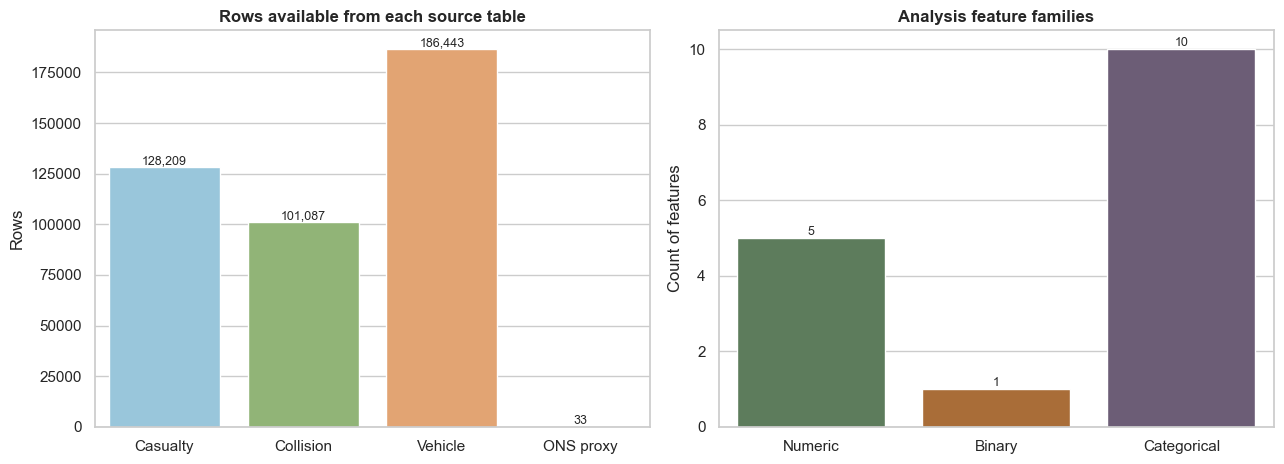

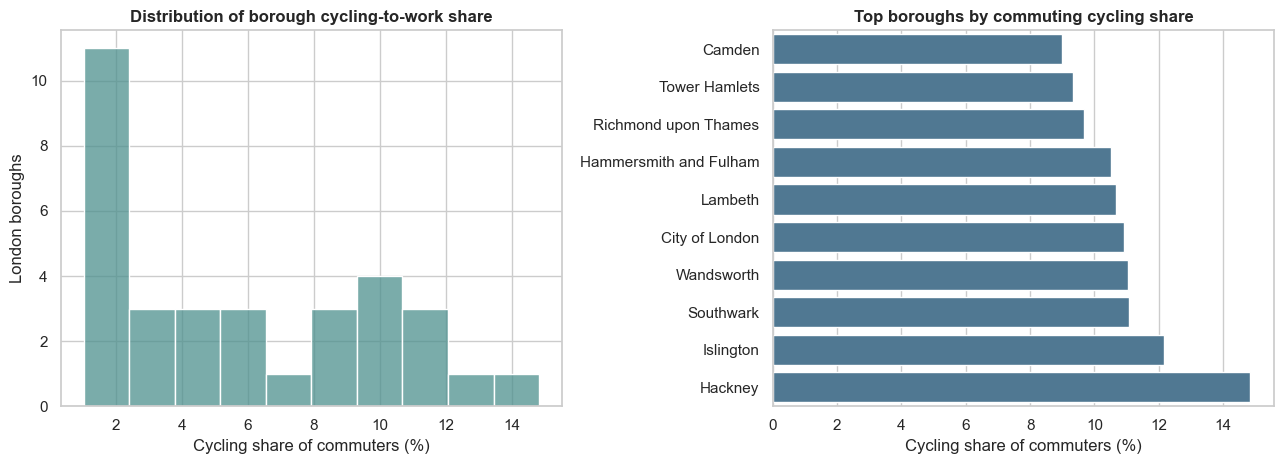

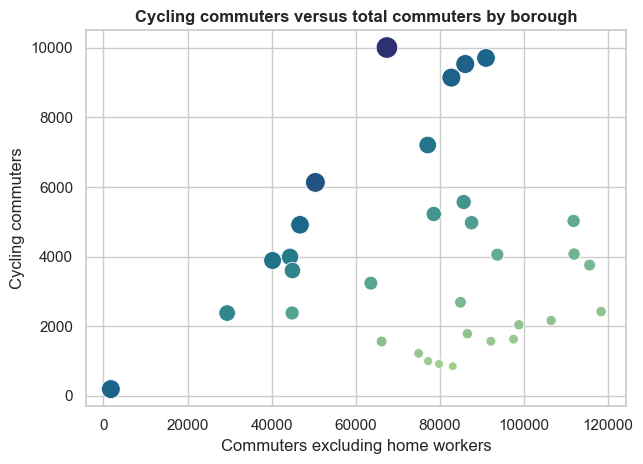

,Field,Example codes,Decoded labels
0,road_type,"6, 1, 3","Single carriageway, Roundabout, Dual carriageway"
1,vehicle_manoeuvre,"19, 9, 5","Going ahead other, Turning right, Moving off"
2,first_point_of_impact,"1, 3, 4","Front, Offside, Nearside"


London boroughs in Census data: 33


,Lower tier local authorities Code,Lower tier local authorities,bike_commuters,commuters_excl_home,cycling_share
0,E09000001,City of London,191,1750,0.109143
1,E09000002,Barking and Dagenham,1218,75014,0.016237
2,E09000003,Barnet,2162,106547,0.020292
3,E09000004,Bexley,995,77291,0.012873
4,E09000005,Brent,4074,112010,0.036372


In [2]:
road_type_map = {
    1: "Roundabout",
    2: "One-way street",
    3: "Dual carriageway",
    6: "Single carriageway",
    7: "Slip road",
    9: "Unknown",
}
junction_map = {
    0: "Not at or within 20m of junction",
    1: "Roundabout",
    2: "Mini-roundabout",
    3: "T or staggered junction",
    5: "Slip road",
    6: "Crossroads",
    7: "More than 4 arms",
    8: "Private drive or entrance",
    9: "Other junction",
    99: "Unknown",
}
light_map = {
    -1: "Data missing",
    1: "Daylight",
    4: "Darkness - lights lit",
    5: "Darkness - lights unlit",
    6: "Darkness - no lighting",
    7: "Darkness - lighting unknown",
}
weather_map = {
    -1: "Data missing",
    1: "Fine no high winds",
    2: "Raining no high winds",
    3: "Snowing no high winds",
    4: "Fine with high winds",
    5: "Raining with high winds",
    6: "Snowing with high winds",
    7: "Fog or mist",
    8: "Other",
    9: "Unknown",
}
surface_map = {
    -1: "Data missing",
    1: "Dry",
    2: "Wet or damp",
    3: "Snow",
    4: "Frost or ice",
    5: "Flood over 3cm deep",
    9: "Unknown",
}
sex_map = {1: "Male", 2: "Female", -1: "Missing", 9: "Unknown"}
vehicle_manoeuvre_map = {
    1: "Reversing",
    2: "Parked",
    3: "Waiting to go ahead",
    4: "Slowing or stopping",
    5: "Moving off",
    6: "U-turn",
    7: "Turning left",
    8: "Waiting to turn left",
    9: "Turning right",
    10: "Waiting to turn right",
    11: "Changing lane left",
    12: "Changing lane right",
    13: "Overtaking offside",
    14: "Passing stationary vehicle",
    15: "Overtaking nearside",
    16: "Going ahead left bend",
    17: "Going ahead right bend",
    19: "Going ahead other",
    99: "Unknown",
}
junction_location_map = {
    0: "Not near junction",
    1: "Approaching junction",
    2: "Cleared junction",
    3: "Leaving roundabout",
    4: "Entering roundabout",
    5: "Leaving main road",
    6: "Entering main road",
    7: "Entering from slip road",
    8: "Mid-junction",
    9: "Unknown",
}
impact_map = {
    0: "No impact",
    1: "Front",
    2: "Back",
    3: "Offside",
    4: "Nearside",
    5: "Roof",
    9: "Unknown",
}


def plot_borough_choropleth(geojson_path, value_df, value_col, title):
    with open(geojson_path, "r", encoding="utf-8") as f:
        geojson = json.load(f)

    value_map = dict(zip(value_df["Lower tier local authorities"], value_df[value_col]))
    series = value_df[value_col].dropna()
    norm = Normalize(vmin=series.min(), vmax=series.max())
    cmap = cm.get_cmap("Reds")

    fig, ax = plt.subplots(figsize=(7.8, 8.6))
    all_x = []
    all_y = []
    for feature in geojson["features"]:
        name = feature["properties"]["name"]
        geom = feature["geometry"]
        colour = "#d9d9d9"
        value = value_map.get(name, np.nan)
        if pd.notna(value):
            colour = cmap(norm(value))

        polygons = [geom["coordinates"]] if geom["type"] == "Polygon" else geom["coordinates"]
        for polygon in polygons:
            exterior = np.asarray(polygon[0])
            all_x.extend(exterior[:, 0].tolist())
            all_y.extend(exterior[:, 1].tolist())
            ax.fill(
                exterior[:, 0],
                exterior[:, 1],
                facecolor=colour,
                edgecolor="white",
                linewidth=0.5,
            )

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.01)
    cbar.set_label("KSI rate per 1,000 cycling commuters")
    ax.set_title(title)
    ax.set_axis_off()
    if all_x and all_y:
        x_margin = (max(all_x) - min(all_x)) * 0.04
        y_margin = (max(all_y) - min(all_y)) * 0.04
        ax.set_xlim(min(all_x) - x_margin, max(all_x) + x_margin)
        ax.set_ylim(min(all_y) - y_margin, max(all_y) + y_margin)
        mean_lat = np.mean(all_y)
        # Correct the apparent shape distortion from plotting longitude/latitude in degrees.
        ax.set_aspect(1 / np.cos(np.deg2rad(mean_lat)))
    plt.tight_layout()
    plt.show()


ts = pd.read_csv(ts061_path)
london_ts = ts[ts["Lower tier local authorities Code"].str.startswith("E09")].copy()

bike = (
    london_ts[london_ts["Method used to travel to workplace (12 categories)"] == "Bicycle"][
        ["Lower tier local authorities Code", "Lower tier local authorities", "Observation"]
    ]
    .rename(columns={"Observation": "bike_commuters"})
)

denominator = (
    london_ts[
        ~london_ts["Method used to travel to workplace (12 categories)"].isin(
            ["Not in employment or aged 15 years and under", "Work mainly at or from home"]
        )
    ]
    .groupby(
        ["Lower tier local authorities Code", "Lower tier local authorities"],
        as_index=False,
    )["Observation"]
    .sum()
    .rename(columns={"Observation": "commuters_excl_home"})
)

borough_share = bike.merge(
    denominator,
    on=["Lower tier local authorities Code", "Lower tier local authorities"],
    how="inner",
)
borough_share["cycling_share"] = borough_share["bike_commuters"] / borough_share["commuters_excl_home"]

source_summary = pd.DataFrame(
    [
        {"Table": "Casualty", "Rows": pd.read_csv(casualty_path, usecols=["collision_index"], low_memory=False).shape[0]},
        {"Table": "Collision", "Rows": pd.read_csv(collision_path, usecols=["collision_index"], low_memory=False).shape[0]},
        {"Table": "Vehicle", "Rows": pd.read_csv(vehicle_path, usecols=["collision_index"], low_memory=False).shape[0]},
        {"Table": "ONS proxy", "Rows": borough_share.shape[0]},
    ]
)
feature_family = pd.DataFrame(
    [
        {"Family": "Numeric", "Count": 5},
        {"Family": "Binary", "Count": 1},
        {"Family": "Categorical", "Count": 10},
    ]
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.barplot(data=source_summary, x="Table", y="Rows", palette=["#8ecae6", "#90be6d", "#f4a261", "#577590"], ax=axes[0])
axes[0].set_title("Rows available from each source table")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rows")
for idx, value in enumerate(source_summary["Rows"]):
    axes[0].text(idx, value, f"{value:,}", ha="center", va="bottom", fontsize=9)

sns.barplot(data=feature_family, x="Family", y="Count", palette=["#588157", "#bc6c25", "#6d597a"], ax=axes[1])
axes[1].set_title("Analysis feature families")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count of features")
for idx, value in enumerate(feature_family["Count"]):
    axes[1].text(idx, value, f"{value}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.histplot(borough_share["cycling_share"] * 100, bins=10, color="#4d908e", edgecolor="white", ax=axes[0])
axes[0].set_title("Distribution of borough cycling-to-work share")
axes[0].set_xlabel("Cycling share of commuters (%)")
axes[0].set_ylabel("London boroughs")

top_boroughs = borough_share.nlargest(10, "cycling_share").sort_values("cycling_share")
sns.barplot(
    data=top_boroughs.assign(cycling_share_pct=top_boroughs["cycling_share"] * 100),
    x="cycling_share_pct",
    y="Lower tier local authorities",
    color="#457b9d",
    ax=axes[1],
)
axes[1].set_title("Top boroughs by commuting cycling share")
axes[1].set_xlabel("Cycling share of commuters (%)")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.6, 4.8))
sns.scatterplot(
    data=borough_share,
    x="commuters_excl_home",
    y="bike_commuters",
    size="cycling_share",
    hue="cycling_share",
    palette="crest",
    sizes=(40, 240),
    legend=False,
    ax=ax,
)
ax.set_title("Cycling commuters versus total commuters by borough")
ax.set_xlabel("Commuters excluding home workers")
ax.set_ylabel("Cycling commuters")
plt.tight_layout()
plt.show()

coding_preview = pd.DataFrame(
    [
        {"Field": "road_type", "Example codes": "6, 1, 3", "Decoded labels": "Single carriageway, Roundabout, Dual carriageway"},
        {"Field": "vehicle_manoeuvre", "Example codes": "19, 9, 5", "Decoded labels": "Going ahead other, Turning right, Moving off"},
        {"Field": "first_point_of_impact", "Example codes": "1, 3, 4", "Decoded labels": "Front, Offside, Nearside"},
    ]
)
display(coding_preview)

print("London boroughs in Census data:", borough_share.shape[0])
borough_share.head()


## Methodology

[[ go back to the top ]](#Table-of-contents)

**Data sources and integration:** the workflow combines DfT casualty, collision and vehicle records with ONS TS061 commuting data and London borough geometry. Cyclist casualties are selected, `cyclist_ksi` is defined from severity, collision context and the matching cyclist vehicle row are merged in, London boroughs are kept, and `cycling_share` is added as a borough-level commuting proxy.

**Feature construction:** the final table contains the outcome `cyclist_ksi`, the proxy `cycling_share`, demographic variables, road and weather variables, vehicle-mechanics variables, and time-of-day indicators. Numeric variables stay continuous, while coded categories are converted to readable labels before modelling.

**Spatial analysis:** descriptive checks review the integrated sample, missingness, and the class imbalance between slight and KSI casualties. Borough-level counts and KSI rates are then calculated and mapped, while correlation and scatter plots compare raw totals with proxy-based rates.

**Machine-learning workflow and interpretation:** the casualty-level table is split with `train_test_split(..., stratify=y, test_size=0.30, random_state=42)`. A preprocessing pipeline applies median and most-frequent imputation, one-hot encoding and scaling before comparing Logistic Regression, Random Forest and Gradient Boosting with recall-focused cross-validation. The best tree-based model is then threshold-tuned and interpreted with confusion matrices, ROC/PR curves, permutation importance and a short Logistic Regression coefficient summary.


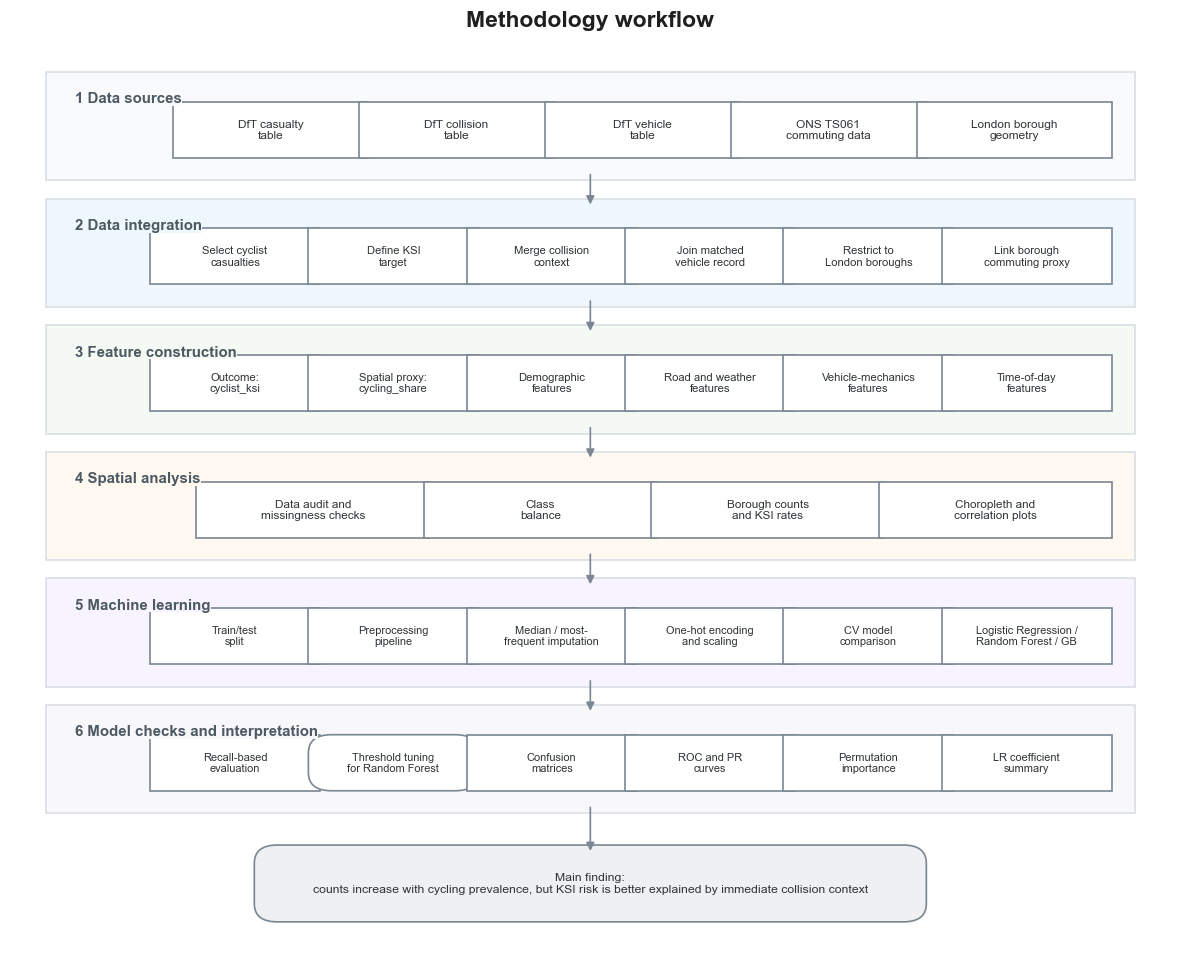

In [3]:
fig, ax = plt.subplots(figsize=(10.8, 8.8), dpi=110)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

border = "#7a8793"
text_color = "#2f3437"
title_color = "#4d5963"
band_edge = "#d7dde2"
box_fill = "#ffffff"

layer_fills = {
    "sources": "#f8fafb",
    "integration": "#eef7fb",
    "features": "#f4faf3",
    "spatial": "#fff9f1",
    "ml": "#f7f4ff",
    "refine": "#f8f8fb",
    "conclusion": "#eef0f2",
}

def draw_box(x, y, w, h, text, fc="white", ec=border, lw=1.1, ls="-", rounded=False, fontsize=9):
    style = "round,pad=0.01,rounding_size=0.02" if rounded else "square,pad=0.01"
    patch = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle=style,
        linewidth=lw,
        edgecolor=ec,
        facecolor=fc,
        linestyle=ls,
    )
    ax.add_patch(patch)
    ax.text(
        x + w / 2,
        y + h / 2,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        color=text_color,
        linespacing=1.15,
        wrap=True,
    )
    return {"x": x, "y": y, "w": w, "h": h}

def straight_connect(start, end, style="-", lw=1.1):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(
            arrowstyle="-|>",
            lw=lw,
            color=border,
            linestyle=style,
            mutation_scale=11,
            shrinkA=2,
            shrinkB=2,
        ),
    )

def draw_band(y, h, title, fill):
    band = draw_box(0.04, y, 0.92, h, "", fc=fill, ec=band_edge, lw=1.0)
    ax.text(
        0.055,
        y + h - 0.012,
        title,
        fontsize=9.8,
        color=title_color,
        weight="bold",
        va="top",
        bbox=dict(facecolor=fill, edgecolor="none", pad=0.2),
    )
    return band

def draw_row(labels, y, box_h, x0=0.16, x1=0.94, gap=0.012, fontsize=7.8, rounded_index=None):
    width = (x1 - x0 - gap * (len(labels) - 1)) / len(labels)
    boxes = []
    for idx, label in enumerate(labels):
        x = x0 + idx * (width + gap)
        boxes.append(
            draw_box(
                x,
                y,
                width,
                box_h,
                label,
                fc=box_fill,
                rounded=(rounded_index is not None and idx in rounded_index),
                fontsize=fontsize,
            )
        )
    return boxes

ax.set_title("Methodology workflow", fontsize=15, pad=12, color="#1f1f1f")

draw_band(0.86, 0.10, "1 Data sources", layer_fills["sources"])
draw_row(
    [
        "DfT casualty\ntable",
        "DfT collision\ntable",
        "DfT vehicle\ntable",
        "ONS TS061\ncommuting data",
        "London borough\ngeometry",
    ],
    y=0.885,
    box_h=0.042,
    x0=0.15,
    x1=0.94,
    gap=0.012,
    fontsize=7.8,
)

draw_band(0.72, 0.10, "2 Data integration", layer_fills["integration"])
draw_row(
    [
        "Select cyclist\ncasualties",
        "Define KSI\ntarget",
        "Merge collision\ncontext",
        "Join matched\nvehicle record",
        "Restrict to\nLondon boroughs",
        "Link borough\ncommuting proxy",
    ],
    y=0.745,
    box_h=0.042,
    x0=0.13,
    x1=0.94,
    gap=0.010,
    fontsize=7.4,
)

draw_band(0.58, 0.10, "3 Feature construction", layer_fills["features"])
draw_row(
    [
        "Outcome:\ncyclist_ksi",
        "Spatial proxy:\ncycling_share",
        "Demographic\nfeatures",
        "Road and weather\nfeatures",
        "Vehicle-mechanics\nfeatures",
        "Time-of-day\nfeatures",
    ],
    y=0.605,
    box_h=0.042,
    x0=0.13,
    x1=0.94,
    gap=0.010,
    fontsize=7.4,
)

draw_band(0.44, 0.10, "4 Spatial analysis", layer_fills["spatial"])
draw_row(
    [
        "Data audit and\nmissingness checks",
        "Class\nbalance",
        "Borough counts\nand KSI rates",
        "Choropleth and\ncorrelation plots",
    ],
    y=0.465,
    box_h=0.042,
    x0=0.17,
    x1=0.94,
    gap=0.015,
    fontsize=7.7,
)

draw_band(0.30, 0.10, "5 Machine learning", layer_fills["ml"])
draw_row(
    [
        "Train/test\nsplit",
        "Preprocessing\npipeline",
        "Median / most-\nfrequent imputation",
        "One-hot encoding\nand scaling",
        "CV model\ncomparison",
        "Logistic Regression /\nRandom Forest / GB",
    ],
    y=0.325,
    box_h=0.042,
    x0=0.13,
    x1=0.94,
    gap=0.010,
    fontsize=7.2,
)

draw_band(0.16, 0.10, "6 Model checks and interpretation", layer_fills["refine"])
draw_row(
    [
        "Recall-based\nevaluation",
        "Threshold tuning\nfor Random Forest",
        "Confusion\nmatrices",
        "ROC and PR\ncurves",
        "Permutation\nimportance",
        "LR coefficient\nsummary",
    ],
    y=0.185,
    box_h=0.042,
    x0=0.13,
    x1=0.94,
    gap=0.010,
    fontsize=7.2,
    rounded_index={1},
)

final_box = draw_box(
    0.22,
    0.04,
    0.56,
    0.065,
    "Main finding:\ncounts increase with cycling prevalence, but KSI risk is better explained by immediate collision context",
    fc=layer_fills["conclusion"],
    ec=border,
    rounded=True,
    fontsize=8.0,
)

center_x = 0.50
straight_connect((center_x, 0.86), (center_x, 0.82))
straight_connect((center_x, 0.72), (center_x, 0.68))
straight_connect((center_x, 0.58), (center_x, 0.54))
straight_connect((center_x, 0.44), (center_x, 0.40))
straight_connect((center_x, 0.30), (center_x, 0.26))
straight_connect((center_x, 0.16), (center_x, 0.105))

plt.tight_layout(pad=0.8)
plt.show()


## Results and discussion

[[ go back to the top ]](#Table-of-contents)

### Data preparation diagnostics

Before modelling, several checks summarise the cleaned cyclist subset. The audit table shows that cyclist casualties, collision context and the cyclist row in the vehicle table can be joined without losing London observations. The missingness chart shows that the selected modelling variables are mostly complete after these joins. The class-balance plot confirms the main modelling issue: slight injuries dominate, so KSI is the minority outcome. Simple profiles for lighting, road surface and the added vehicle-mechanics variables help show why these fields are useful.

### Borough-level findings

The cyclist-only London subset contains **5,283 casualties**, and **18.9%** of them are KSI. Excluding City of London, cycling share is strongly associated with cyclist casualty counts (**r = 0.847, p < 0.001**), but not with cyclist KSI rate per 1,000 cycling commuters (**r = -0.095, p = 0.603**). The map and scatter plots therefore show a simple point: boroughs with more cycling commuters tend to record more cyclist casualties, but higher cycling prevalence does not automatically mean higher severe-injury *risk* once the commuting proxy is used to standardise rates. In short, `count != risk`.

### Model comparison

Given that a cyclist casualty has already happened, which conditions are linked to a KSI outcome? After adding the vehicle-mechanics variables, **Logistic Regression** still performs best, with mean CV recall **0.575**, holdout recall **0.640** and ROC-AUC **0.657**. Random Forest also improves, reaching holdout recall **0.540**, but Logistic Regression remains the strongest default model. Gradient Boosting still gives the highest accuracy (**0.803**) while recall falls to **0.037**, so it mainly predicts the majority slight-injury class. The ROC curves are close, but the precision-recall curves and recall summary still favour Logistic Regression.

### Threshold tuning

Random Forest remains the stronger tree-based model, so it is used for threshold tuning. The recall-maximising threshold in cross-validation is again **0.1**. On the holdout set, lowering the threshold from **0.5** to **0.1** raises recall from **0.540** to **1.000**, but accuracy falls from **0.658** to **0.189** and F1 changes only a little. The threshold plot shows a clear trade-off: the model can catch almost all serious cases, but it then over-flags many slight injuries. Even so, Logistic Regression remains the stronger default model in this workflow.

### Interpretation

The interpretation plots show that the added vehicle-mechanics variables are useful rather than random noise. The Logistic Regression coefficient table now includes **vehicle manoeuvre**, **junction location** and **first point of impact** among the strongest predictors, together with darkness without lighting and poor surface conditions. The tree-based interpretation also highlights age and immediate collision setting. These are patterns in the data, not proof of causality, but they suggest that severe cyclist outcomes are explained more by the immediate collision environment than by borough cycling prevalence alone.

### Critical reflection

Three limitations remain. First, Census 2021 commuting data were collected during a pandemic-affected period, so `cycling_share` is an imperfect proxy for normal cycling exposure. Second, borough commuting prevalence is contextual and does not describe individual trip purpose or route choice. Third, the DfT open data only include police-reported incidents. The results are therefore **predictive rather than causal**.


London cyclist casualties: 5,283
KSI share: 18.910%
Count correlation r = 0.847, p = 9.86e-10
KSI rate correlation r = -0.095, p = 0.603


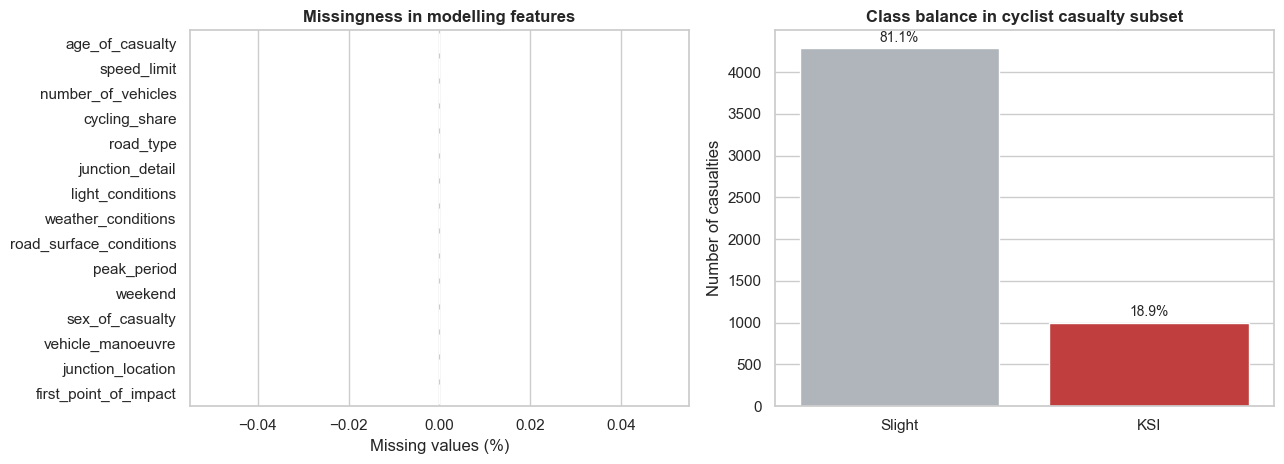

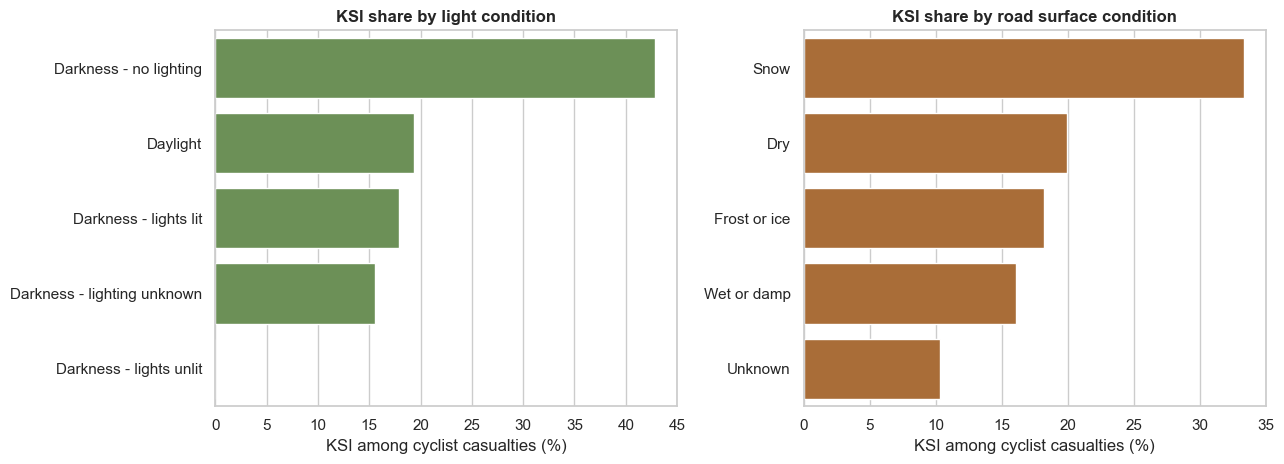

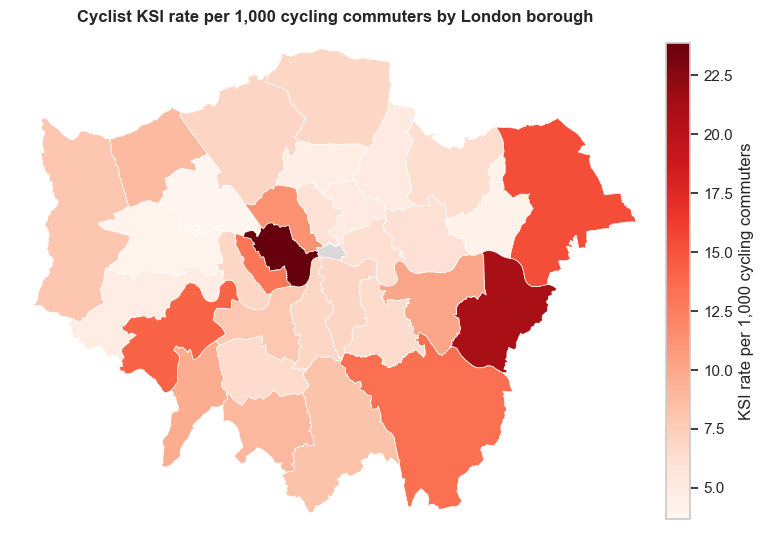

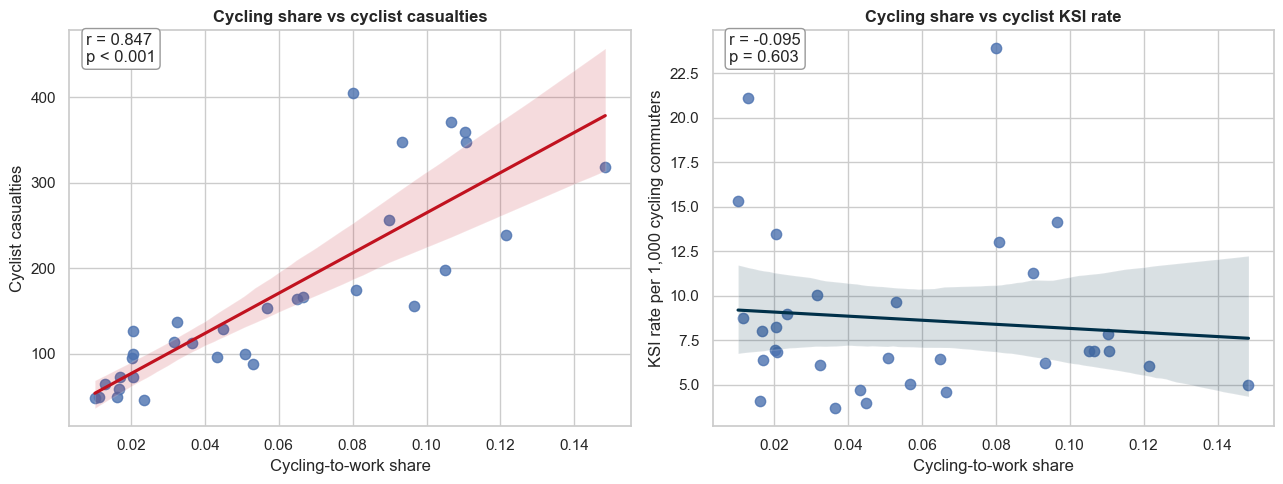

In [4]:
collision_cols = [
    "collision_index",
    "number_of_vehicles",
    "day_of_week",
    "time",
    "local_authority_ons_district",
    "speed_limit",
    "road_type",
    "junction_detail",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
]
casualty_cols = [
    "collision_index",
    "vehicle_reference",
    "casualty_reference",
    "casualty_type",
    "sex_of_casualty",
    "age_of_casualty",
    "casualty_severity",
]
vehicle_cols = [
    "collision_index",
    "vehicle_reference",
    "vehicle_manoeuvre",
    "junction_location",
    "first_point_of_impact",
]

collisions = pd.read_csv(collision_path, usecols=collision_cols, low_memory=False)
casualties = pd.read_csv(casualty_path, usecols=casualty_cols, low_memory=False)
vehicles = pd.read_csv(vehicle_path, usecols=vehicle_cols, low_memory=False)

cyclist_casualties = casualties[casualties["casualty_type"] == 1].copy()
cyclist_casualties["cyclist_ksi"] = cyclist_casualties["casualty_severity"].isin([1, 2]).astype(int)

cyclist_df = cyclist_casualties.merge(
    collisions,
    on="collision_index",
    how="left",
    validate="many_to_one",
)
cyclist_df = cyclist_df[
    cyclist_df["local_authority_ons_district"].fillna("").str.startswith("E09")
].copy()

cyclist_df = cyclist_df.merge(
    borough_share[
        [
            "Lower tier local authorities Code",
            "Lower tier local authorities",
            "bike_commuters",
            "commuters_excl_home",
            "cycling_share",
        ]
    ],
    left_on="local_authority_ons_district",
    right_on="Lower tier local authorities Code",
    how="left",
)
cyclist_df = cyclist_df.merge(
    vehicles,
    on=["collision_index", "vehicle_reference"],
    how="left",
    validate="many_to_one",
)

cyclist_df["borough_name"] = cyclist_df["Lower tier local authorities"]
cyclist_df["road_type"] = cyclist_df["road_type"].map(road_type_map).fillna("Other")
cyclist_df["junction_detail"] = cyclist_df["junction_detail"].map(junction_map).fillna("Other")
cyclist_df["light_conditions"] = cyclist_df["light_conditions"].map(light_map).fillna("Other")
cyclist_df["weather_conditions"] = cyclist_df["weather_conditions"].map(weather_map).fillna("Other")
cyclist_df["road_surface_conditions"] = cyclist_df["road_surface_conditions"].map(surface_map).fillna("Other")
cyclist_df["sex_of_casualty"] = cyclist_df["sex_of_casualty"].map(sex_map).fillna("Other")
cyclist_df["vehicle_manoeuvre"] = cyclist_df["vehicle_manoeuvre"].map(vehicle_manoeuvre_map).fillna("Other")
cyclist_df["junction_location"] = cyclist_df["junction_location"].map(junction_location_map).fillna("Other")
cyclist_df["first_point_of_impact"] = cyclist_df["first_point_of_impact"].map(impact_map).fillna("Other")

cyclist_df["hour"] = pd.to_datetime(cyclist_df["time"], format="%H:%M", errors="coerce").dt.hour
cyclist_df["weekend"] = cyclist_df["day_of_week"].isin([1, 7]).astype(int)
cyclist_df["peak_period"] = pd.cut(
    cyclist_df["hour"],
    bins=[-1, 6, 9, 15, 19, 23],
    labels=["Night", "Morning peak", "Daytime", "Evening peak", "Night late"],
).astype("object").fillna("Unknown")

borough_summary = (
    cyclist_df.groupby("borough_name", as_index=False)
    .agg(
        cyclist_casualties=("casualty_reference", "count"),
        cyclist_ksi=("cyclist_ksi", "sum"),
        bike_commuters=("bike_commuters", "first"),
        cycling_share=("cycling_share", "first"),
    )
    .dropna(subset=["bike_commuters", "cycling_share"])
)
borough_summary["ksi_rate_per_1000_cycle_commuters"] = (
    borough_summary["cyclist_ksi"] / borough_summary["bike_commuters"] * 1000
)
borough_summary["casualty_rate_per_1000_cycle_commuters"] = (
    borough_summary["cyclist_casualties"] / borough_summary["bike_commuters"] * 1000
)

borough_plot_df = borough_summary[borough_summary["borough_name"] != "City of London"].copy()
count_corr, count_p = pearsonr(
    borough_plot_df["cycling_share"], borough_plot_df["cyclist_casualties"]
)
rate_corr, rate_p = pearsonr(
    borough_plot_df["cycling_share"], borough_plot_df["ksi_rate_per_1000_cycle_commuters"]
)

print(f"London cyclist casualties: {len(cyclist_df):,}")
print(f"KSI share: {cyclist_df['cyclist_ksi'].mean():.3%}")
print(f"Count correlation r = {count_corr:.3f}, p = {count_p:.3g}")
print(f"KSI rate correlation r = {rate_corr:.3f}, p = {rate_p:.3f}")

diagnostic_features = [
    "age_of_casualty",
    "speed_limit",
    "number_of_vehicles",
    "cycling_share",
    "road_type",
    "junction_detail",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "peak_period",
    "weekend",
    "sex_of_casualty",
    "vehicle_manoeuvre",
    "junction_location",
    "first_point_of_impact",
]
missing_pct = cyclist_df[diagnostic_features].isna().mean().mul(100).sort_values(ascending=False)
class_counts = cyclist_df["cyclist_ksi"].map({0: "Slight", 1: "KSI"}).value_counts().reindex(["Slight", "KSI"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="#8ecae6", ax=axes[0])
axes[0].set_title("Missingness in modelling features")
axes[0].set_xlabel("Missing values (%)")
axes[0].set_ylabel("")

sns.barplot(x=class_counts.index, y=class_counts.values, palette=["#adb5bd", "#d62828"], ax=axes[1])
axes[1].set_title("Class balance in cyclist casualty subset")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of casualties")
for idx, value in enumerate(class_counts.values):
    share = value / class_counts.sum()
    axes[1].text(idx, value + 40, f"{share:.1%}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

light_profile = (
    cyclist_df.groupby("light_conditions")["cyclist_ksi"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .mul(100)
    .reset_index(name="KSI percentage")
)
surface_profile = (
    cyclist_df.groupby("road_surface_conditions")["cyclist_ksi"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .mul(100)
    .reset_index(name="KSI percentage")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.barplot(data=light_profile, x="KSI percentage", y="light_conditions", color="#6a994e", ax=axes[0])
axes[0].set_title("KSI share by light condition")
axes[0].set_xlabel("KSI among cyclist casualties (%)")
axes[0].set_ylabel("")

sns.barplot(
    data=surface_profile,
    x="KSI percentage",
    y="road_surface_conditions",
    color="#bc6c25",
    ax=axes[1],
)
axes[1].set_title("KSI share by road surface condition")
axes[1].set_xlabel("KSI among cyclist casualties (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

plot_borough_choropleth(
    geojson_path,
    borough_plot_df.rename(columns={"borough_name": "Lower tier local authorities"}),
    "ksi_rate_per_1000_cycle_commuters",
    "Cyclist KSI rate per 1,000 cycling commuters by London borough",
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(
    data=borough_plot_df,
    x="cycling_share",
    y="cyclist_casualties",
    scatter_kws={"s": 55, "alpha": 0.8},
    line_kws={"color": "#c1121f"},
    ax=axes[0],
)
axes[0].set_title("Cycling share vs cyclist casualties")
axes[0].set_xlabel("Cycling-to-work share")
axes[0].set_ylabel("Cyclist casualties")
axes[0].text(
    0.03,
    0.92,
    f"r = {count_corr:.3f}\np < 0.001",
    transform=axes[0].transAxes,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#999999"),
)

sns.regplot(
    data=borough_plot_df,
    x="cycling_share",
    y="ksi_rate_per_1000_cycle_commuters",
    scatter_kws={"s": 55, "alpha": 0.8},
    line_kws={"color": "#003049"},
    ax=axes[1],
)
axes[1].set_title("Cycling share vs cyclist KSI rate")
axes[1].set_xlabel("Cycling-to-work share")
axes[1].set_ylabel("KSI rate per 1,000 cycling commuters")
axes[1].text(
    0.03,
    0.92,
    f"r = {rate_corr:.3f}\np = {rate_p:.3f}",
    transform=axes[1].transAxes,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#999999"),
)

plt.tight_layout()
plt.show()


,Step,Rows,Share of previous step
0,Raw casualty table,128209,NaN
1,Cyclist casualties only,16458,0.128
2,Merged with collision table,16458,1.000
3,Joined cyclist vehicle row,16458,1.000
4,London cyclist subset,5283,0.321
5,Rows with modelling target,5283,1.000


,Check,Value
0,Cyclist rows with matched vehicle record,5283.0
1,Vehicle join rate,1.0
2,Unique vehicle manoeuvre labels,17.0
3,Unique impact labels,6.0


,borough_name,cyclist_ksi,age_of_casualty,speed_limit,number_of_vehicles,junction_detail,vehicle_manoeuvre,junction_location,first_point_of_impact,light_conditions,road_surface_conditions,cycling_share,peak_period
0,Brent,0,30,30,2,Other,Overtaking nearside,Cleared junction,Front,Daylight,Dry,0.036372,Morning peak
1,Barnet,1,41,50,2,Not at or within 20m of junction,Changing lane left,Leaving roundabout,Front,Daylight,Dry,0.020292,Evening peak
2,Wandsworth,0,54,20,2,Other,Unknown,Unknown,Unknown,Daylight,Dry,0.110456,Morning peak
3,Hackney,0,26,20,2,Other,Unknown,Unknown,Front,Darkness - lights lit,Wet or damp,0.148386,Morning peak
4,Wandsworth,0,26,20,2,Other,Going ahead other,Cleared junction,Front,Daylight,Dry,0.110456,Daytime
5,Hackney,0,-1,20,2,Other,Unknown,Unknown,Front,Daylight,Dry,0.148386,Evening peak
6,Richmond upon Thames,0,53,30,2,Not at or within 20m of junction,Slowing or stopping,Not near junction,Front,Darkness - lights lit,Wet or damp,0.096611,Night late
7,Wandsworth,0,25,20,2,Other,Going ahead other,Mid-junction,Offside,Daylight,Dry,0.110456,Morning peak


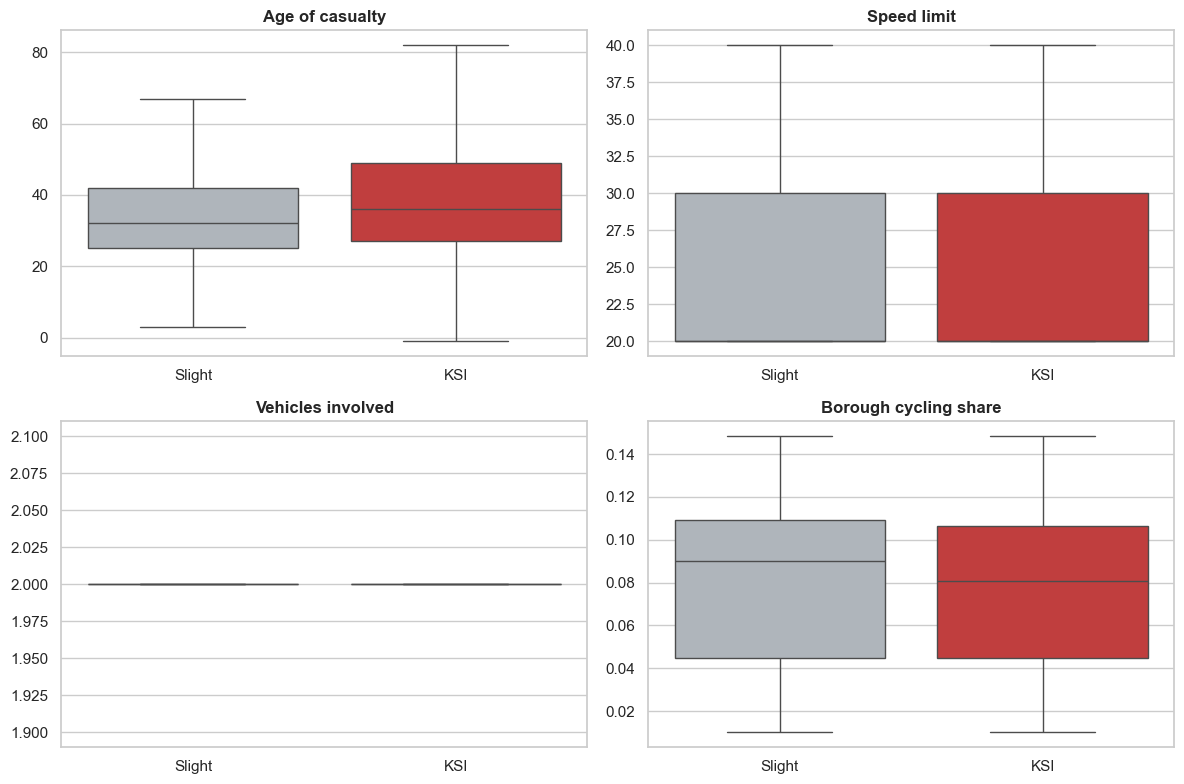

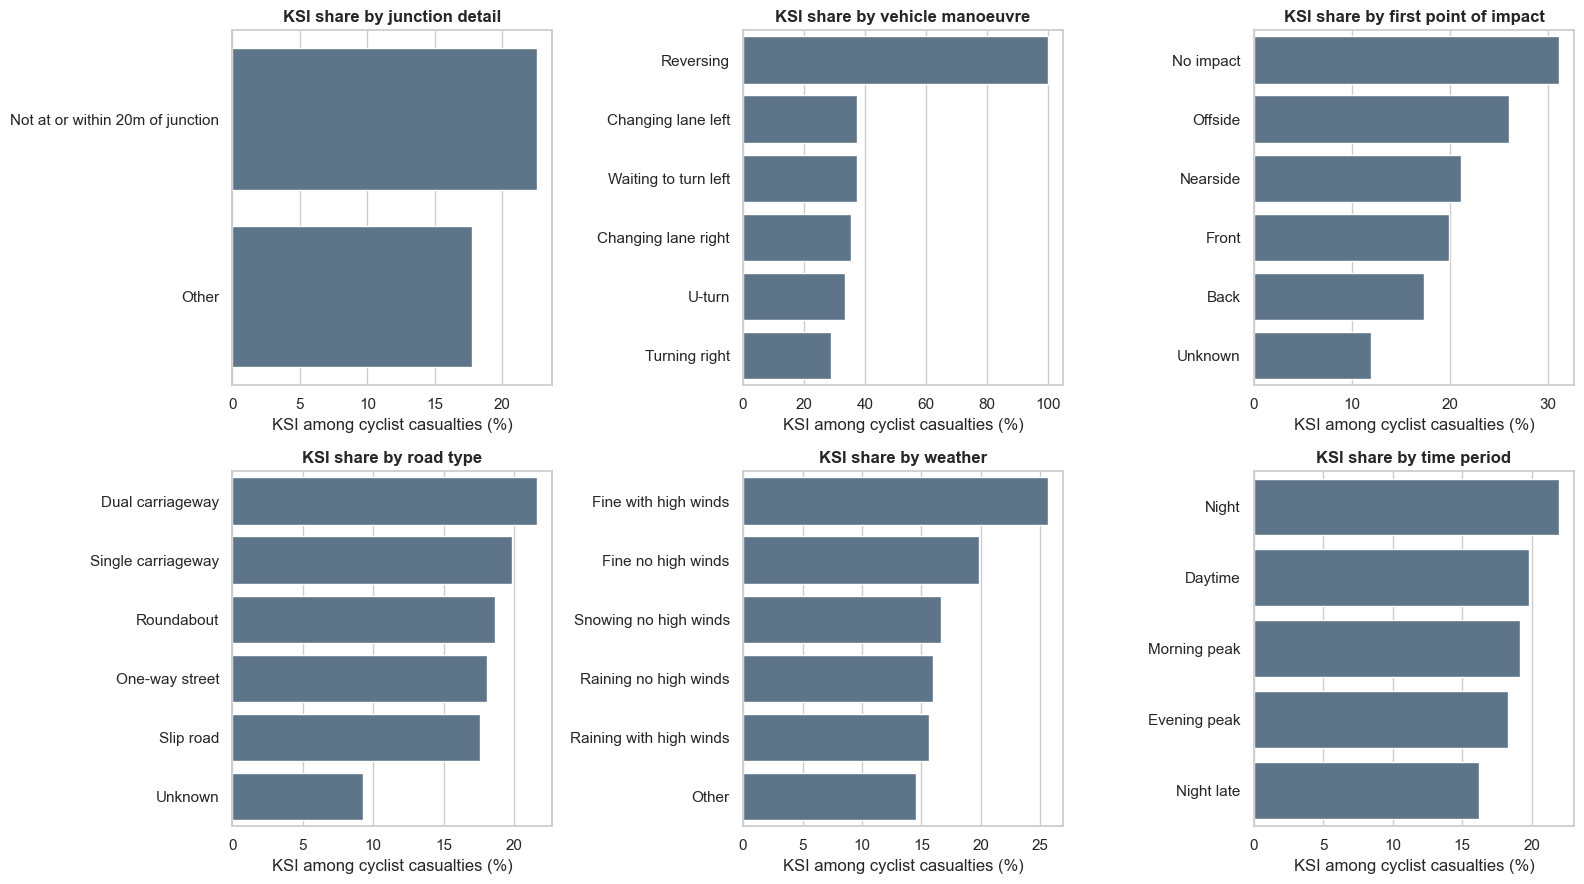

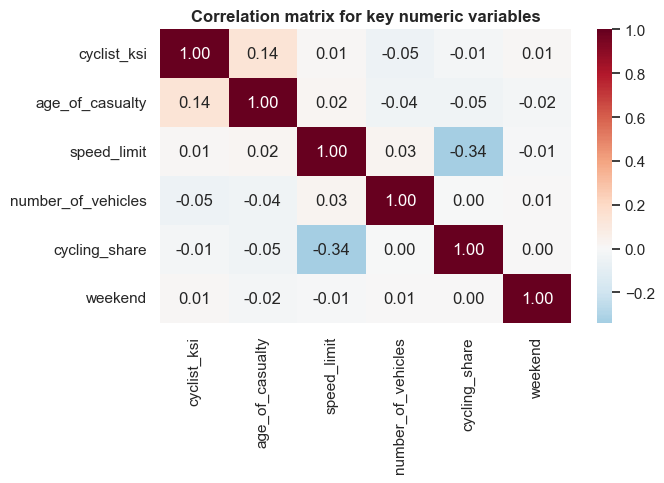

In [5]:
cleaning_audit = pd.DataFrame(
    [
        {"Step": "Raw casualty table", "Rows": len(casualties)},
        {"Step": "Cyclist casualties only", "Rows": len(cyclist_casualties)},
        {"Step": "Merged with collision table", "Rows": len(cyclist_casualties.merge(collisions, on="collision_index", how="left"))},
        {"Step": "Joined cyclist vehicle row", "Rows": len(cyclist_casualties.merge(vehicles, on=["collision_index", "vehicle_reference"], how="left"))},
        {"Step": "London cyclist subset", "Rows": len(cyclist_df)},
        {"Step": "Rows with modelling target", "Rows": model_df.shape[0] if "model_df" in globals() else len(cyclist_df)},
    ]
)
cleaning_audit["Share of previous step"] = cleaning_audit["Rows"].div(cleaning_audit["Rows"].shift(1)).round(3)
display(cleaning_audit)

vehicle_merge_summary = pd.DataFrame(
    [
        {"Check": "Cyclist rows with matched vehicle record", "Value": int(cyclist_df["vehicle_manoeuvre"].notna().sum())},
        {"Check": "Vehicle join rate", "Value": round(float(cyclist_df["vehicle_manoeuvre"].notna().mean()), 3)},
        {"Check": "Unique vehicle manoeuvre labels", "Value": int(cyclist_df["vehicle_manoeuvre"].nunique())},
        {"Check": "Unique impact labels", "Value": int(cyclist_df["first_point_of_impact"].nunique())},
    ]
)
display(vehicle_merge_summary)

preview_cols = [
    "borough_name",
    "cyclist_ksi",
    "age_of_casualty",
    "speed_limit",
    "number_of_vehicles",
    "junction_detail",
    "vehicle_manoeuvre",
    "junction_location",
    "first_point_of_impact",
    "light_conditions",
    "road_surface_conditions",
    "cycling_share",
    "peak_period",
]
display(cyclist_df[preview_cols].sample(8, random_state=42).reset_index(drop=True))

numeric_plot_df = cyclist_df[
    ["cyclist_ksi", "age_of_casualty", "speed_limit", "number_of_vehicles", "cycling_share"]
].copy()
numeric_plot_df["Severity group"] = numeric_plot_df["cyclist_ksi"].map({0: "Slight", 1: "KSI"})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
numeric_cols = ["age_of_casualty", "speed_limit", "number_of_vehicles", "cycling_share"]
titles = ["Age of casualty", "Speed limit", "Vehicles involved", "Borough cycling share"]
for ax, col, title in zip(axes.flat, numeric_cols, titles):
    sns.boxplot(
        data=numeric_plot_df,
        x="Severity group",
        y=col,
        palette=["#adb5bd", "#d62828"],
        showfliers=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

category_specs = [
    ("junction_detail", "KSI share by junction detail"),
    ("vehicle_manoeuvre", "KSI share by vehicle manoeuvre"),
    ("first_point_of_impact", "KSI share by first point of impact"),
    ("road_type", "KSI share by road type"),
    ("weather_conditions", "KSI share by weather"),
    ("peak_period", "KSI share by time period"),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, (col, title) in zip(axes.flat, category_specs):
    temp = (
        cyclist_df.groupby(col)["cyclist_ksi"]
        .mean()
        .sort_values(ascending=False)
        .head(6)
        .mul(100)
        .reset_index(name="KSI percentage")
    )
    sns.barplot(data=temp, x="KSI percentage", y=col, color="#577590", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("KSI among cyclist casualties (%)")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

corr_cols = ["cyclist_ksi", "age_of_casualty", "speed_limit", "number_of_vehicles", "cycling_share", "weekend"]
plt.figure(figsize=(7, 5))
sns.heatmap(cyclist_df[corr_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation matrix for key numeric variables")
plt.tight_layout()
plt.show()


In [6]:
from sklearn.base import clone

feature_cols = [
    "age_of_casualty",
    "speed_limit",
    "number_of_vehicles",
    "cycling_share",
    "road_type",
    "junction_detail",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "peak_period",
    "weekend",
    "sex_of_casualty",
    "vehicle_manoeuvre",
    "junction_location",
    "first_point_of_impact",
]

model_df = cyclist_df[feature_cols + ["cyclist_ksi"]].copy()
X = model_df[feature_cols]
y = model_df["cyclist_ksi"]

numeric_features = [
    "age_of_casualty",
    "speed_limit",
    "number_of_vehicles",
    "cycling_share",
    "weekend",
]
categorical_features = [
    "road_type",
    "junction_detail",
    "light_conditions",
    "weather_conditions",
    "road_surface_conditions",
    "peak_period",
    "sex_of_casualty",
    "vehicle_manoeuvre",
    "junction_location",
    "first_point_of_impact",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            drop="first",
                            sparse_output=False,
                        ),
                    ),
                ]
            ),
            categorical_features,
        ),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                solver="liblinear",
            ),
        ),
    ]
)

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=42,
                n_jobs=1,
            ),
        ),
    ]
)

gb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", GradientBoostingClassifier(random_state=42)),
    ]
)

rf_grid = GridSearchCV(
    rf_pipe,
    param_grid={
        "model__n_estimators": [200, 300],
        "model__max_depth": [10, None],
        "model__min_samples_leaf": [1, 3],
    },
    scoring="recall",
    cv=cv,
    n_jobs=1,
    refit=True,
)

gb_grid = GridSearchCV(
    gb_pipe,
    param_grid={
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3],
    },
    scoring="recall",
    cv=cv,
    n_jobs=1,
    refit=True,
)

results = []
fitted_models = {}

lr_cv_scores = cross_val_score(lr_model, X_train, y_train, cv=cv, scoring="recall", n_jobs=1)
lr_model.fit(X_train, y_train)
lr_probs = lr_model.predict_proba(X_test)[:, 1]
lr_preds = (lr_probs >= 0.5).astype(int)
fitted_models["Logistic Regression"] = lr_model
results.append(
    {
        "Model": "Logistic Regression",
        "Best CV Recall": lr_cv_scores.mean(),
        "Test Recall": recall_score(y_test, lr_preds),
        "Test F1": f1_score(y_test, lr_preds),
        "Test ROC-AUC": roc_auc_score(y_test, lr_probs),
        "Test Accuracy": accuracy_score(y_test, lr_preds),
    }
)

rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.5).astype(int)
fitted_models["Random Forest"] = rf_model
results.append(
    {
        "Model": "Random Forest",
        "Best CV Recall": rf_grid.best_score_,
        "Test Recall": recall_score(y_test, rf_preds),
        "Test F1": f1_score(y_test, rf_preds),
        "Test ROC-AUC": roc_auc_score(y_test, rf_probs),
        "Test Accuracy": accuracy_score(y_test, rf_preds),
    }
)

gb_grid.fit(X_train, y_train)
gb_model = gb_grid.best_estimator_
gb_probs = gb_model.predict_proba(X_test)[:, 1]
gb_preds = (gb_probs >= 0.5).astype(int)
fitted_models["Gradient Boosting"] = gb_model
results.append(
    {
        "Model": "Gradient Boosting",
        "Best CV Recall": gb_grid.best_score_,
        "Test Recall": recall_score(y_test, gb_preds),
        "Test F1": f1_score(y_test, gb_preds),
        "Test ROC-AUC": roc_auc_score(y_test, gb_probs),
        "Test Accuracy": accuracy_score(y_test, gb_preds),
    }
)

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="recall", n_jobs=1)
gb_cv_scores = cross_val_score(gb_model, X_train, y_train, cv=cv, scoring="recall", n_jobs=1)

cv_detail_df = pd.DataFrame(
    {
        "Fold": list(range(1, len(lr_cv_scores) + 1)) * 3,
        "Recall": np.concatenate([lr_cv_scores, rf_cv_scores, gb_cv_scores]),
        "Model": (
            ["Logistic Regression"] * len(lr_cv_scores)
            + ["Random Forest"] * len(rf_cv_scores)
            + ["Gradient Boosting"] * len(gb_cv_scores)
        ),
    }
)

results_df = pd.DataFrame(results).sort_values("Best CV Recall", ascending=False).reset_index(drop=True)
display(results_df.round(3))

transformed_feature_count = len(lr_model.named_steps["preprocessor"].get_feature_names_out())
preprocess_summary = pd.DataFrame(
    [
        {"Component": "Numeric input features", "Count": len(numeric_features)},
        {"Component": "Categorical input features", "Count": len(categorical_features)},
        {"Component": "Transformed model features", "Count": transformed_feature_count},
        {"Component": "Training rows", "Count": len(X_train)},
        {"Component": "Test rows", "Count": len(X_test)},
    ]
)

rf_search_table = (
    pd.DataFrame(rf_grid.cv_results_)[
        [
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__min_samples_leaf",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
        ]
    ]
    .rename(
        columns={
            "param_model__n_estimators": "n_estimators",
            "param_model__max_depth": "max_depth",
            "param_model__min_samples_leaf": "min_samples_leaf",
            "mean_test_score": "mean_cv_recall",
            "std_test_score": "std_cv_recall",
            "rank_test_score": "rank",
        }
    )
    .sort_values(["rank", "mean_cv_recall"])
    .reset_index(drop=True)
)

gb_search_table = (
    pd.DataFrame(gb_grid.cv_results_)[
        [
            "param_model__n_estimators",
            "param_model__learning_rate",
            "param_model__max_depth",
            "mean_test_score",
            "std_test_score",
            "rank_test_score",
        ]
    ]
    .rename(
        columns={
            "param_model__n_estimators": "n_estimators",
            "param_model__learning_rate": "learning_rate",
            "param_model__max_depth": "max_depth",
            "mean_test_score": "mean_cv_recall",
            "std_test_score": "std_cv_recall",
            "rank_test_score": "rank",
        }
    )
    .sort_values(["rank", "mean_cv_recall"])
    .reset_index(drop=True)
)

best_model_name = results_df.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
best_tree_name = (
    results_df[results_df["Model"].isin(["Random Forest", "Gradient Boosting"])]
    .sort_values("Best CV Recall", ascending=False)
    .iloc[0]["Model"]
)
best_tree_model = fitted_models[best_tree_name]

if best_tree_name == "Random Forest":
    print("Best Random Forest parameters:", rf_grid.best_params_)
else:
    print("Best Gradient Boosting parameters:", gb_grid.best_params_)

thresholds = np.arange(0.1, 1.0, 0.1)
threshold_records = []
for threshold in thresholds:
    fold_recalls = []
    for train_idx, valid_idx in cv.split(X_train, y_train):
        fold_model = clone(best_tree_model)
        fold_model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        fold_probs = fold_model.predict_proba(X_train.iloc[valid_idx])[:, 1]
        fold_preds = (fold_probs >= threshold).astype(int)
        fold_recalls.append(recall_score(y_train.iloc[valid_idx], fold_preds))
    threshold_records.append(
        {
            "Threshold": threshold,
            "Mean CV Recall": np.mean(fold_recalls),
        }
    )

threshold_df = pd.DataFrame(threshold_records)
best_threshold = threshold_df.sort_values(["Mean CV Recall", "Threshold"], ascending=[False, True]).iloc[0][
    "Threshold"
]
best_tree_probs = best_tree_model.predict_proba(X_test)[:, 1]

threshold_metric_df = []
for threshold in thresholds:
    preds = (best_tree_probs >= threshold).astype(int)
    threshold_metric_df.append(
        {
            "Threshold": threshold,
            "Recall": recall_score(y_test, preds),
            "Precision": precision_score(y_test, preds, zero_division=0),
            "F1": f1_score(y_test, preds),
            "Accuracy": accuracy_score(y_test, preds),
        }
    )
threshold_metric_df = pd.DataFrame(threshold_metric_df)

threshold_comparison = pd.DataFrame(
    [
        {
            "Setting": f"{best_tree_name} @ 0.5",
            "Recall": recall_score(y_test, (best_tree_probs >= 0.5).astype(int)),
            "F1": f1_score(y_test, (best_tree_probs >= 0.5).astype(int)),
            "Accuracy": accuracy_score(y_test, (best_tree_probs >= 0.5).astype(int)),
        },
        {
            "Setting": f"{best_tree_name} @ {best_threshold:.1f}",
            "Recall": recall_score(y_test, (best_tree_probs >= best_threshold).astype(int)),
            "F1": f1_score(y_test, (best_tree_probs >= best_threshold).astype(int)),
            "Accuracy": accuracy_score(y_test, (best_tree_probs >= best_threshold).astype(int)),
        },
    ]
)
display(threshold_comparison.round(3))


,Model,Best CV Recall,Test Recall,Test F1,Test ROC-AUC,Test Accuracy
0,Logistic Regression,0.575,0.640,0.375,0.657,0.596
1,Random Forest,0.443,0.540,0.374,0.665,0.658
2,Gradient Boosting,0.059,0.037,0.066,0.643,0.803


Best Random Forest parameters: {'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}


,Setting,Recall,F1,Accuracy
0,Random Forest @ 0.5,0.54,0.374,0.658
1,Random Forest @ 0.1,1.00,0.318,0.189


,Component,Count
0,Numeric input features,5
1,Categorical input features,10
2,Transformed model features,61
3,Training rows,3698
4,Test rows,1585


,n_estimators,max_depth,min_samples_leaf,mean_cv_recall,std_cv_recall,rank
0,300,10,3,0.443,0.068,1
1,200,10,3,0.438,0.063,2
2,200,10,1,0.392,0.061,3
3,300,10,1,0.390,0.058,4
4,300,None,3,0.256,0.029,5
5,200,None,3,0.249,0.029,6


,n_estimators,learning_rate,max_depth,mean_cv_recall,std_cv_recall,rank
0,200,0.10,3,0.059,0.013,1
1,100,0.10,3,0.043,0.015,2
2,200,0.05,3,0.037,0.014,3
3,200,0.10,2,0.031,0.012,4
4,100,0.05,3,0.027,0.010,5
5,200,0.05,2,0.024,0.003,6


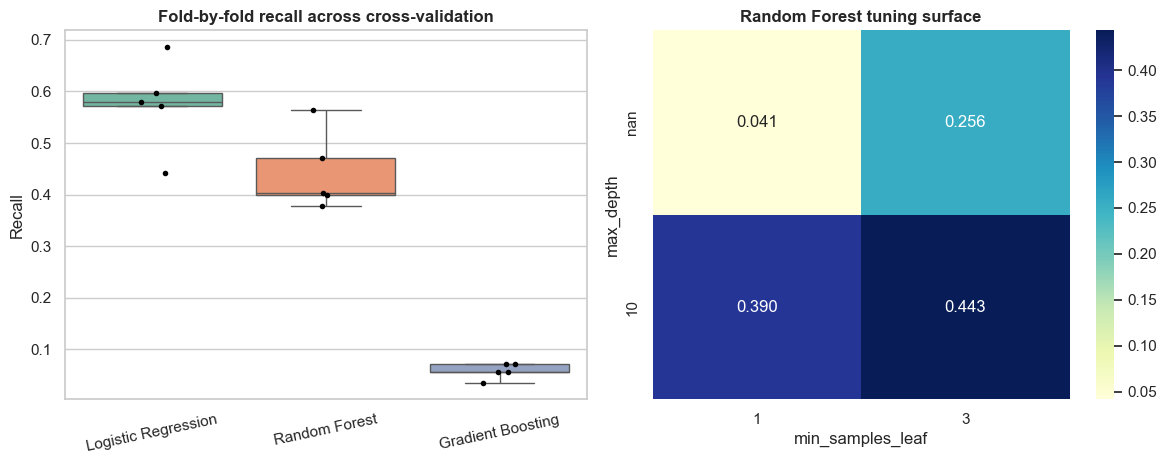

In [7]:
display(preprocess_summary)
display(rf_search_table.head(6).round(3))
display(gb_search_table.head(6).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sns.boxplot(data=cv_detail_df, x="Model", y="Recall", palette="Set2", ax=axes[0], showfliers=False)
sns.stripplot(data=cv_detail_df, x="Model", y="Recall", color="black", size=4, ax=axes[0])
axes[0].set_title("Fold-by-fold recall across cross-validation")
axes[0].set_xlabel("")
axes[0].set_ylabel("Recall")
axes[0].tick_params(axis="x", rotation=12)

rf_heat_source = rf_search_table[rf_search_table["n_estimators"] == rf_search_table["n_estimators"].max()].copy()
rf_heat_source["max_depth"] = rf_heat_source["max_depth"].astype(str)
rf_heat = rf_heat_source.pivot(index="max_depth", columns="min_samples_leaf", values="mean_cv_recall")
sns.heatmap(rf_heat, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Random Forest tuning surface")
axes[1].set_xlabel("min_samples_leaf")
axes[1].set_ylabel("max_depth")

plt.tight_layout()
plt.show()


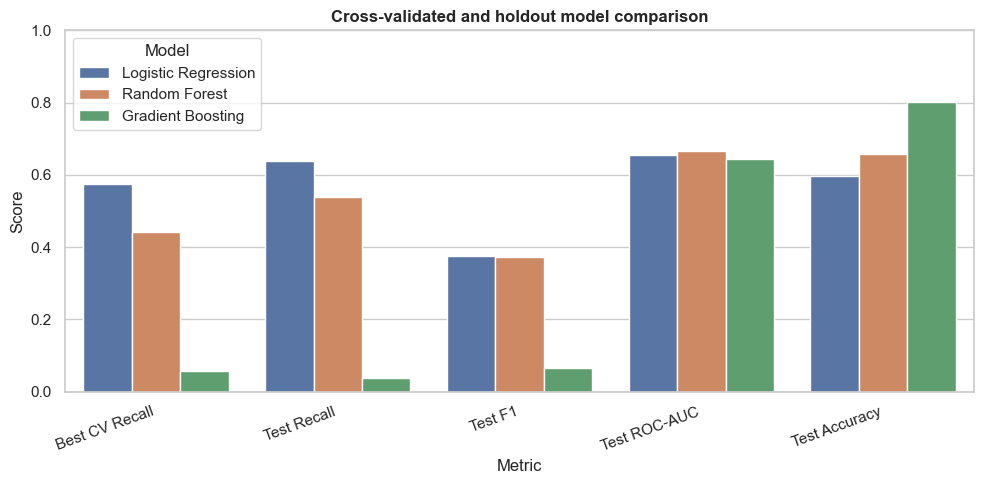

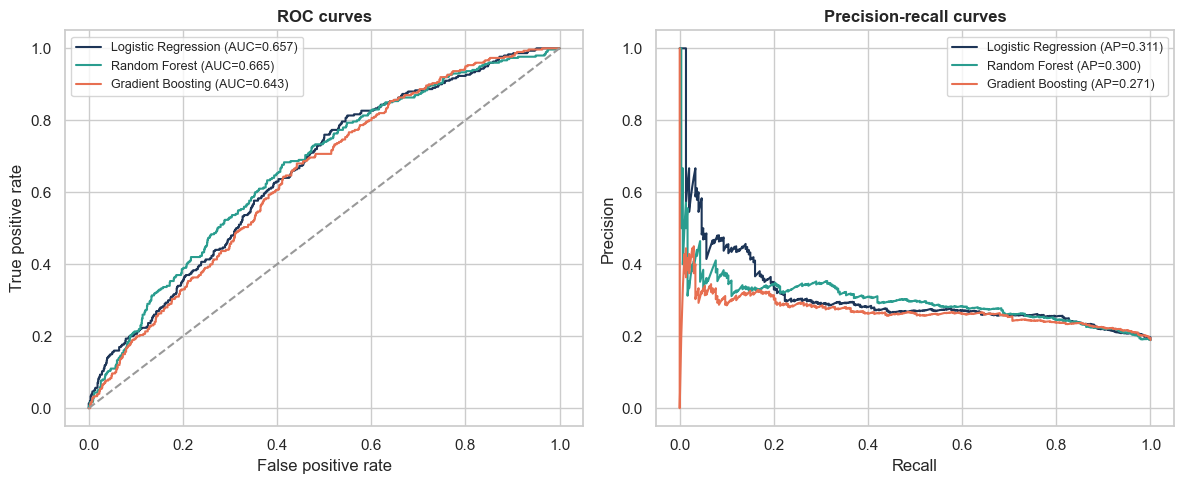

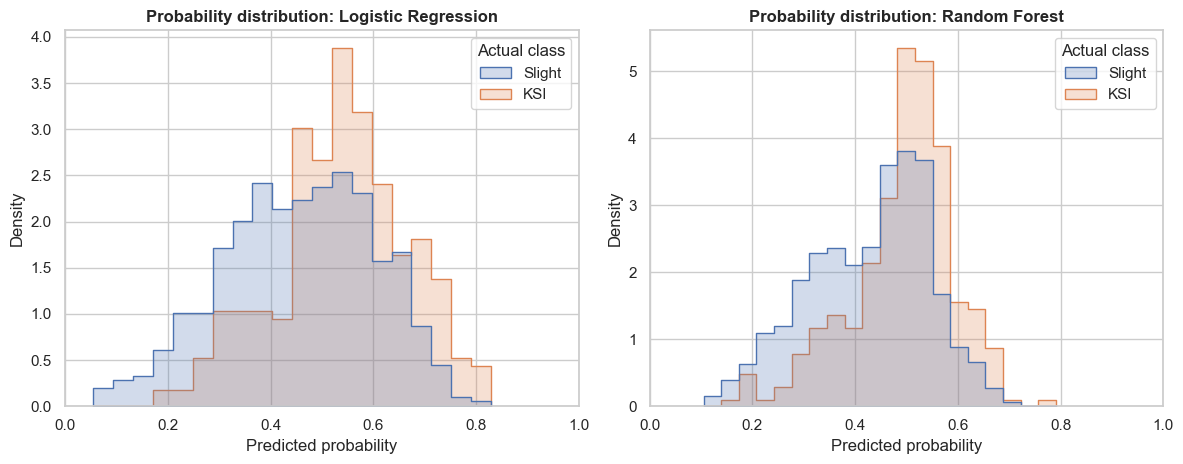

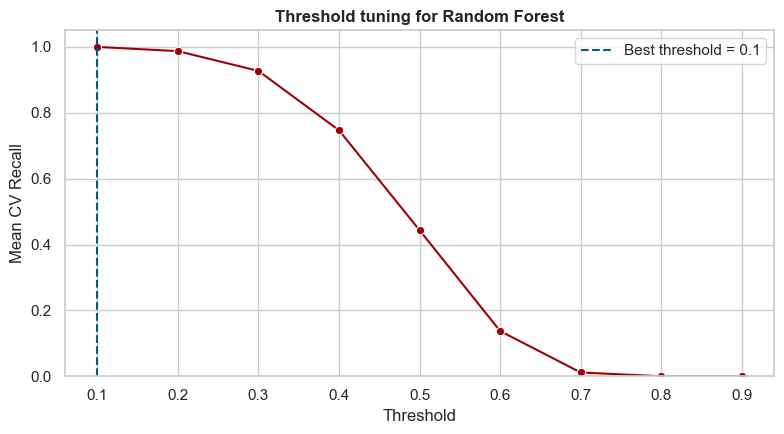

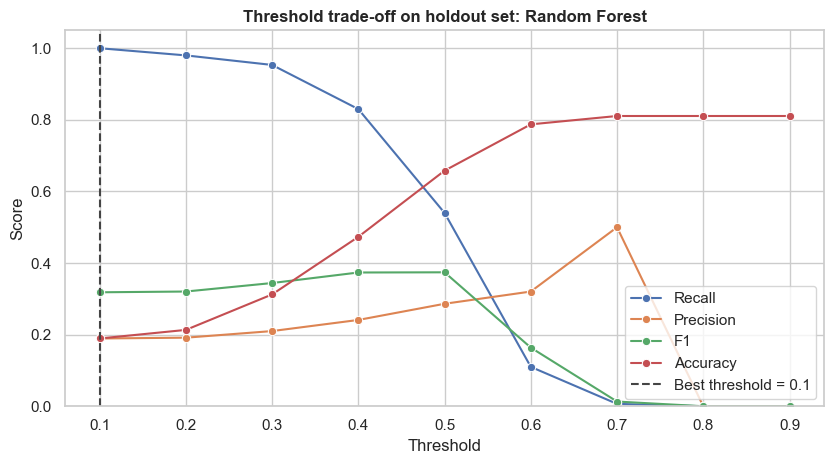

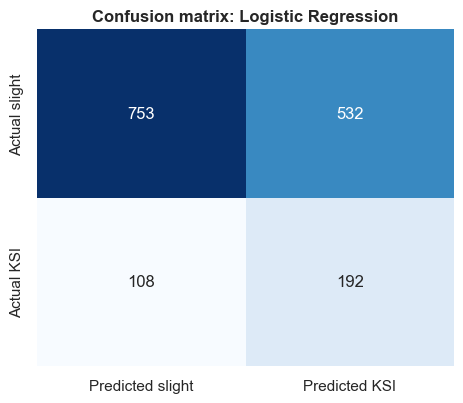

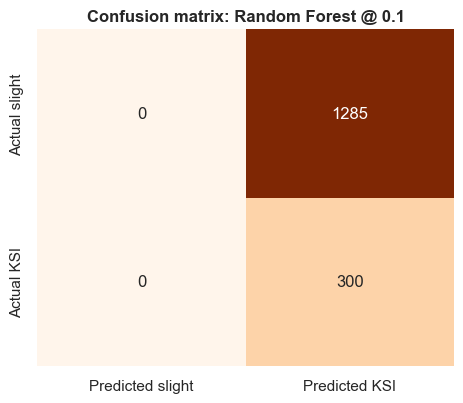

In [8]:
metric_plot_df = results_df.melt(
    id_vars="Model",
    value_vars=["Best CV Recall", "Test Recall", "Test F1", "Test ROC-AUC", "Test Accuracy"],
    var_name="Metric",
    value_name="Score",
)

plt.figure(figsize=(10, 5))
sns.barplot(data=metric_plot_df, x="Metric", y="Score", hue="Model")
plt.title("Cross-validated and holdout model comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

probability_map = {
    "Logistic Regression": lr_probs,
    "Random Forest": rf_probs,
    "Gradient Boosting": gb_probs,
}
curve_colours = {
    "Logistic Regression": "#1d3557",
    "Random Forest": "#2a9d8f",
    "Gradient Boosting": "#e76f51",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for model_name, probs in probability_map.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    precision, recall, _ = precision_recall_curve(y_test, probs)
    axes[0].plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={roc_auc_score(y_test, probs):.3f})",
        color=curve_colours[model_name],
    )
    axes[1].plot(
        recall,
        precision,
        label=f"{model_name} (AP={average_precision_score(y_test, probs):.3f})",
        color=curve_colours[model_name],
    )

axes[0].plot([0, 1], [0, 1], linestyle="--", color="#999999")
axes[0].set_title("ROC curves")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].legend(fontsize=9)

axes[1].set_title("Precision-recall curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

probability_plot_df = pd.concat(
    [
        pd.DataFrame(
            {
                "Model": "Logistic Regression",
                "Predicted probability": lr_probs,
                "Actual class": y_test.map({0: "Slight", 1: "KSI"}).values,
            }
        ),
        pd.DataFrame(
            {
                "Model": best_tree_name,
                "Predicted probability": best_tree_probs,
                "Actual class": y_test.map({0: "Slight", 1: "KSI"}).values,
            }
        ),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, model_name in zip(axes, ["Logistic Regression", best_tree_name]):
    temp = probability_plot_df[probability_plot_df["Model"] == model_name]
    sns.histplot(
        data=temp,
        x="Predicted probability",
        hue="Actual class",
        bins=20,
        stat="density",
        common_norm=False,
        element="step",
        ax=ax,
    )
    ax.set_title(f"Probability distribution: {model_name}")
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
sns.lineplot(data=threshold_df, x="Threshold", y="Mean CV Recall", marker="o", color="#9d0208")
plt.axvline(best_threshold, linestyle="--", color="#005f73", label=f"Best threshold = {best_threshold:.1f}")
plt.title(f"Threshold tuning for {best_tree_name}")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

threshold_long_df = threshold_metric_df.melt(
    id_vars="Threshold",
    value_vars=["Recall", "Precision", "F1", "Accuracy"],
    var_name="Metric",
    value_name="Score",
)
plt.figure(figsize=(8.5, 4.8))
sns.lineplot(data=threshold_long_df, x="Threshold", y="Score", hue="Metric", marker="o")
plt.axvline(best_threshold, linestyle="--", color="#444444", label=f"Best threshold = {best_threshold:.1f}")
plt.title(f"Threshold trade-off on holdout set: {best_tree_name}")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

if best_model_name == "Logistic Regression":
    final_probs = lr_probs
elif best_model_name == "Random Forest":
    final_probs = rf_probs
else:
    final_probs = gb_probs

final_preds = (final_probs >= 0.5).astype(int)
cmatrix = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(4.8, 4.2))
sns.heatmap(
    cmatrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted slight", "Predicted KSI"],
    yticklabels=["Actual slight", "Actual KSI"],
)
plt.title(f"Confusion matrix: {best_model_name}")
plt.tight_layout()
plt.show()

tuned_tree_preds = (best_tree_probs >= best_threshold).astype(int)
tuned_cmatrix = confusion_matrix(y_test, tuned_tree_preds)
plt.figure(figsize=(4.8, 4.2))
sns.heatmap(
    tuned_cmatrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    cbar=False,
    xticklabels=["Predicted slight", "Predicted KSI"],
    yticklabels=["Actual slight", "Actual KSI"],
)
plt.title(f"Confusion matrix: {best_tree_name} @ {best_threshold:.1f}")
plt.tight_layout()
plt.show()


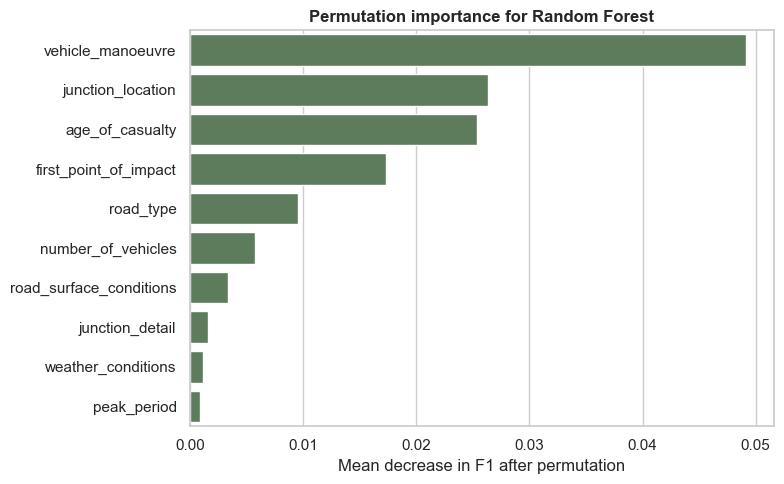

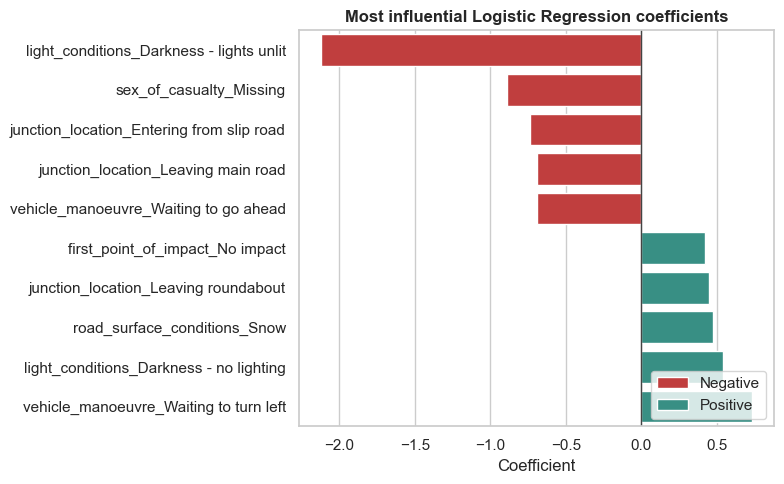

,Most positive feature,Positive coef,Most negative feature,Negative coef
0,vehicle_manoeuvre_Waiting to turn left,0.737,light_conditions_Darkness - lights unlit,-2.123
1,light_conditions_Darkness - no lighting,0.544,sex_of_casualty_Missing,-0.892
2,road_surface_conditions_Snow,0.475,junction_location_Entering from slip road,-0.740
3,junction_location_Leaving roundabout,0.447,junction_location_Leaving main road,-0.693
4,first_point_of_impact_No impact,0.422,vehicle_manoeuvre_Waiting to go ahead,-0.693


In [9]:
perm = permutation_importance(
    best_tree_model,
    X_test,
    y_test,
    n_repeats=12,
    random_state=42,
    scoring="f1",
)

perm_df = (
    pd.DataFrame(
        {
            "Feature": X_test.columns,
            "Importance": perm.importances_mean,
        }
    )
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=perm_df.head(10), y="Feature", x="Importance", color="#588157")
plt.title(f"Permutation importance for {best_tree_name}")
plt.xlabel("Mean decrease in F1 after permutation")
plt.ylabel("")
plt.tight_layout()
plt.show()

lr_feature_names = (
    lr_model.named_steps["preprocessor"]
    .get_feature_names_out()
    .tolist()
)
coef_df = pd.DataFrame(
    {
        "Feature": [name.replace("num__", "").replace("cat__", "") for name in lr_feature_names],
        "Coefficient": lr_model.named_steps["model"].coef_[0],
    }
).sort_values("Coefficient")

top_negative = coef_df.head(5).reset_index(drop=True)
top_positive = coef_df.tail(5).sort_values("Coefficient", ascending=False).reset_index(drop=True)

coefficient_table = pd.DataFrame(
    {
        "Most positive feature": top_positive["Feature"],
        "Positive coef": top_positive["Coefficient"].round(3),
        "Most negative feature": top_negative["Feature"],
        "Negative coef": top_negative["Coefficient"].round(3),
    }
)

coef_plot_df = pd.concat(
    [
        top_positive.assign(Direction="Positive"),
        top_negative.assign(Direction="Negative"),
    ],
    ignore_index=True,
).sort_values("Coefficient")

plt.figure(figsize=(8, 5))
sns.barplot(
    data=coef_plot_df,
    y="Feature",
    x="Coefficient",
    hue="Direction",
    dodge=False,
    palette={"Positive": "#2a9d8f", "Negative": "#d62828"},
)
plt.axvline(0, color="#444444", linewidth=1)
plt.title("Most influential Logistic Regression coefficients")
plt.xlabel("Coefficient")
plt.ylabel("")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

display(coefficient_table)


## Conclusion

[[ go back to the top ]](#Table-of-contents)

This notebook used borough-level commuting proxies and casualty-level machine learning to analyse cyclist KSI risk in London. For **RQ1**, boroughs with higher cycling-to-work share record more cyclist casualties in absolute terms, but not clearly higher cyclist KSI rates once the commuting proxy is used to standardise counts. For **RQ2**, collision-level context matters more than borough prevalence alone: age, junction environment, lighting, road surface and time of day are the most informative predictors of KSI. For **RQ3**, Logistic Regression is the strongest model under a recall-focused evaluation, while threshold tuning shows that Random Forest can be pushed toward near-complete sensitivity at a major cost in false positives. Borough cycling prevalence alone does not explain cyclist danger; collision-level conditions matter more.


## References

[[ go back to the top ]](#Table-of-contents)

Adams, T. and Aldred, R. (2020) *Cycling Injury Risk in London: Impacts of Road Characteristics and Infrastructure*. Findings. Available at: https://doi.org/10.32866/001c.18226

Agheli, L. and Aghabayk, K. (2025) *How does distraction affect cyclists' severe crashes? A hybrid CatBoost-SHAP and random parameters binary logit approach*. Available at: https://www.sciencedirect.com/science/article/abs/pii/S000145752400441X

Aldred, R., Goodman, A., Gulliver, J. and Woodcock, J. (2018) *Cycling injury risk in London: A case-control study exploring the impact of cycle volumes, motor vehicle volumes, and road characteristics including speed limits*. Accident Analysis & Prevention, 117, pp. 75-84. Available at: https://doi.org/10.1016/j.aap.2018.03.003

Department for Transport (2025) *Road safety open data*. Available at: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data

Department for Transport (2025) *Reported road casualties Great Britain: pedal cyclist factsheet 2024*. Available at: https://www.gov.uk/government/statistics/reported-road-casualties-great-britain-pedal-cyclist-factsheet-2024

Hyman, J. and Ignacio, C. (2024) *Road Traffic Injury Prevention: Bicycle*. Available at: https://link.springer.com/article/10.1007/s40719-024-00274-y

Jaber, A., Al-Masaeid, H., Abuhamdah, A. and Al-Hyari, I. (2021) *An Analysis of Factors Affecting the Severity of Cycling Crashes Using Binary Regression Model*. Sustainability, 13(12), 6945. Available at: https://doi.org/10.3390/su13126945

Mason-Jones, A.J., Turrell, S., Zavala Gomez, G., Tait, C. and Lovelace, R. (2022) *Severe and fatal cycling crash injury in Britain: Time to make urban cycling safer*. Journal of Urban Health, 99, pp. 334-343. Available at: https://doi.org/10.1007/s11524-022-00617-7

Office for National Statistics (2024) *TS061: Method used to travel to work, Census 2021, version 6*. Available at: https://www.ons.gov.uk/datasets/TS061/editions/2021/versions/6

Scarano, B. et al. (2025) *Cyclist crash severity modeling: A hybrid approach of XGBoost-SHAP and random parameters logit with heterogeneity in means and variances*. Available at: https://pubmed.ncbi.nlm.nih.gov/40483075/

Ye, Y., Zhong, C. and Suel, E. (2024) *Unpacking the perceived cycling safety of road environment using street view imagery and cycle accident data*. Available at: https://pubmed.ncbi.nlm.nih.gov/38924963/
